#Day2

In [1]:
pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files
uploaded = files.upload()

Saving inventory_demand_stockout_risk.csv to inventory_demand_stockout_risk.csv


In [4]:
df = pd.read_csv("inventory_demand_stockout_risk.csv")

In [5]:
df.info

<bound method DataFrame.info of      product_id        date store_id  current_stock  daily_demand  \
0         P1000  2024-01-01       S7            213           114   
1         P1001  2024-01-02      S20            152            87   
2         P1002  2024-01-03      S15            209            62   
3         P1003  2024-01-04      S11            400           103   
4         P1004  2024-01-05       S8             60           114   
...         ...         ...      ...            ...           ...   
2795      P3795  2031-08-27       S9            464            11   
2796      P3796  2031-08-28       S1            104            48   
2797      P3797  2031-08-29       S8            227            72   
2798      P3798  2031-08-30       S6            246            38   
2799      P3799  2031-08-31       S6            187            70   

      lead_time_days  supplier_reliability_score promotion_active  \
0                  5                          72               No   
1                  7                          84               No   
2                 10                          61               No   
3                 10                          61               No   
4                  9                          75               No   
...              ...                         ...              ...   
2795              10                          86              Yes   
2796              10                          83              Yes   
2797               9                          78               No   
2798               4                          67              Yes   
2799               7                          61               No   

     weather_impact stockout_risk  
0            Medium            No  
1              High           Yes  
2               Low            No  
3               Low            No  
4            Medium            No  
...             ...           ...  
2795            Low           Yes  
2796         Medium           Yes  
2797         Medium            No  
2798           High           Yes  
2799            Low            No  

[2800 rows x 10 columns]>

In [6]:
df.shape

(2800, 10)

The dataset contains 2800 rows and 10 columns

In [7]:
df.columns

Index(['product_id', 'date', 'store_id', 'current_stock', 'daily_demand',
       'lead_time_days', 'supplier_reliability_score', 'promotion_active',
       'weather_impact', 'stockout_risk'],
      dtype='object')

Column	                Meaning
product_id-	            unique product identifier
store_id-	              store identifier
current_stock-	          current inventory level
daily_demand-	          expected demand per day
lead_time_days-	        supplier delivery time
supplier_reliability_score-	supplier performance indicator
promotion_active-	      promotion running or not
weather_impact-       	weather affecting demand
stockout_risk-          target variable

In [8]:
df.describe()

,current_stock,daily_demand,lead_time_days,supplier_reliability_score
count,2800.000000,2800.000000,2800.000000,2800.000000
mean,250.288214,61.925714,7.432143,79.252857
std,143.466643,32.981750,4.006029,11.235899
min,0.000000,5.000000,1.000000,60.000000
25%,125.000000,33.000000,4.000000,70.000000
50%,249.000000,62.000000,7.000000,79.000000
75%,376.250000,90.000000,11.000000,89.000000
max,499.000000,119.000000,14.000000,99.000000


Average daily demand is 62
Average current stock is 251
significant variation in demand as well as in stock.

In [9]:
df.isnull().sum()

,0
product_id,0
date,0
store_id,0
current_stock,0
daily_demand,0
lead_time_days,0
supplier_reliability_score,0
promotion_active,0
weather_impact,0
stockout_risk,0


No missing value in the dataset.

In [10]:
df["stockout_risk"].value_counts()

,count
stockout_risk,
No,2110
Yes,690


In [11]:
df["stockout_risk"].value_counts(normalize=True) * 100

,proportion
stockout_risk,
No,75.357143
Yes,24.642857


Out of 2800 observations, stock out risk is in 690 i.e. 24.64%.

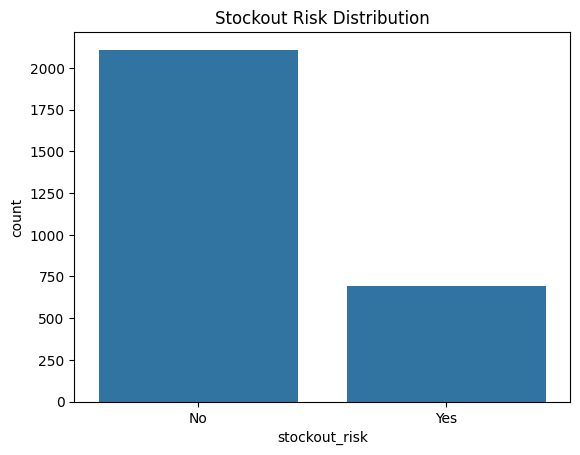

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="stockout_risk", data=df)
plt.title("Stockout Risk Distribution")
plt.show()

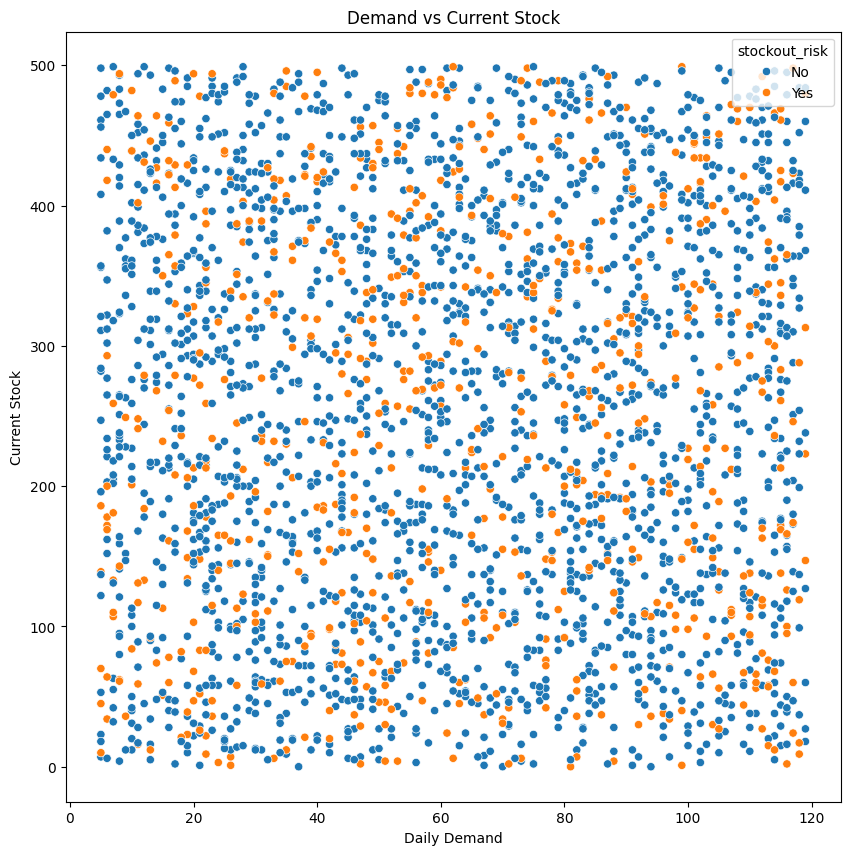

In [13]:
plt.figure(figsize=(10,10))

sns.scatterplot(x="daily_demand", y="current_stock", hue="stockout_risk", data=df)

plt.title("Demand vs Current Stock")
plt.xlabel("Daily Demand")
plt.ylabel("Current Stock")

plt.show()

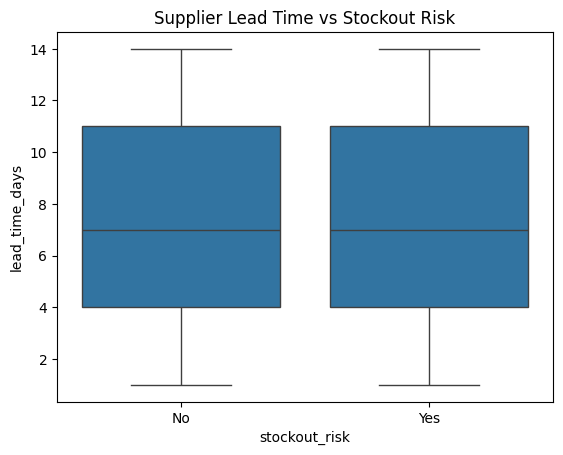

In [14]:
sns.boxplot(x="stockout_risk", y="lead_time_days", data=df)

plt.title("Supplier Lead Time vs Stockout Risk")

plt.show()

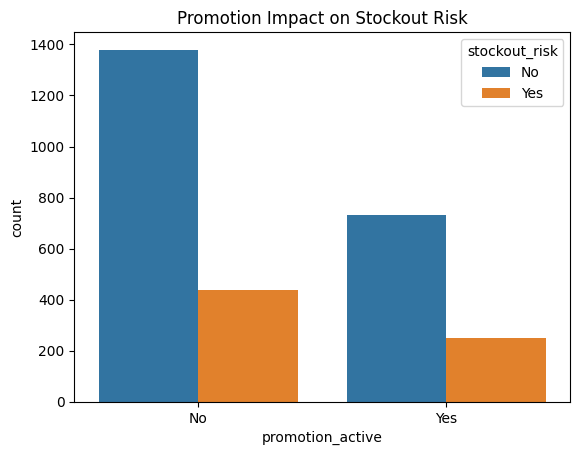

In [15]:
sns.countplot(x="promotion_active", hue="stockout_risk", data=df)

plt.title("Promotion Impact on Stockout Risk")

plt.show()

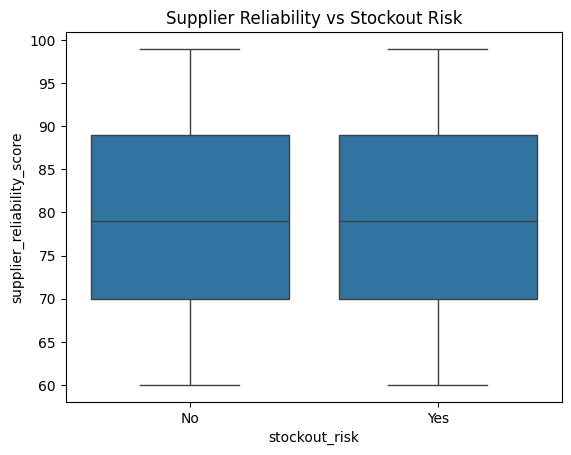

In [16]:
sns.boxplot(x="stockout_risk", y="supplier_reliability_score", data=df)

plt.title("Supplier Reliability vs Stockout Risk")

plt.show()

#Day3

In [17]:
df_clean = df.copy()

In [18]:
df_clean.isnull().sum()

,0
product_id,0
date,0
store_id,0
current_stock,0
daily_demand,0
lead_time_days,0
supplier_reliability_score,0
promotion_active,0
weather_impact,0
stockout_risk,0


Above execution implies that there are no null values in the dataset.

In [19]:
df_clean.duplicated().sum()

np.int64(0)

There are 0 duplicate rows in the dataset.

Now convert the categorical columns into binary outputs.

In [20]:
df_clean['promotion_active'] = df_clean["promotion_active"].map({"Yes":1,"No":0})

In [21]:
df_clean["stockout_risk"] = df_clean["stockout_risk"].map({"Yes":1,"No":0})

In [22]:
df_clean["weather_impact"] = df_clean["weather_impact"].map({"Low":0,"Medium":1,"High":2})

In [23]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   product_id                  2800 non-null   object
 1   date                        2800 non-null   object
 2   store_id                    2800 non-null   object
 3   current_stock               2800 non-null   int64 
 4   daily_demand                2800 non-null   int64 
 5   lead_time_days              2800 non-null   int64 
 6   supplier_reliability_score  2800 non-null   int64 
 7   promotion_active            2800 non-null   int64 
 8   weather_impact              2800 non-null   int64 
 9   stockout_risk               2800 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 218.9+ KB


In [24]:
df_clean["stock_coverage_days"] = df_clean["current_stock"] / df_clean["daily_demand"]

stock_coverage_days shows how many days inventory will last.

<Axes: xlabel='daily_demand'>

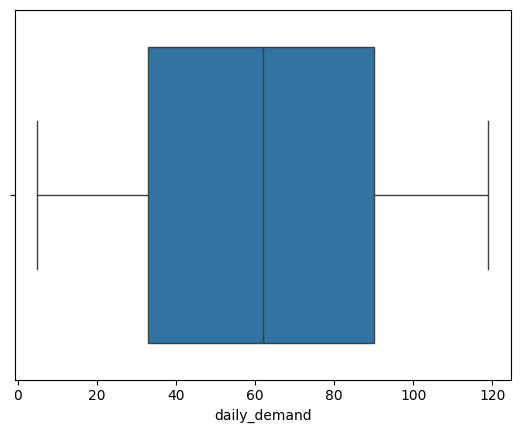

In [25]:
import seaborn as sns

sns.boxplot(x=df_clean["daily_demand"])

In [26]:
df_clean.to_csv("clean_inventory_dataset.csv", index=False)

Data Cleaning Summary

1. No missing value in supplier_reliability_score.
2. No missing value in Weather impact.
3. No Duplicate records found.
4. Categorical variables encoded into numerical values.
5. Inventory coverage feature created.

#Day4

target variable- stockout_risk

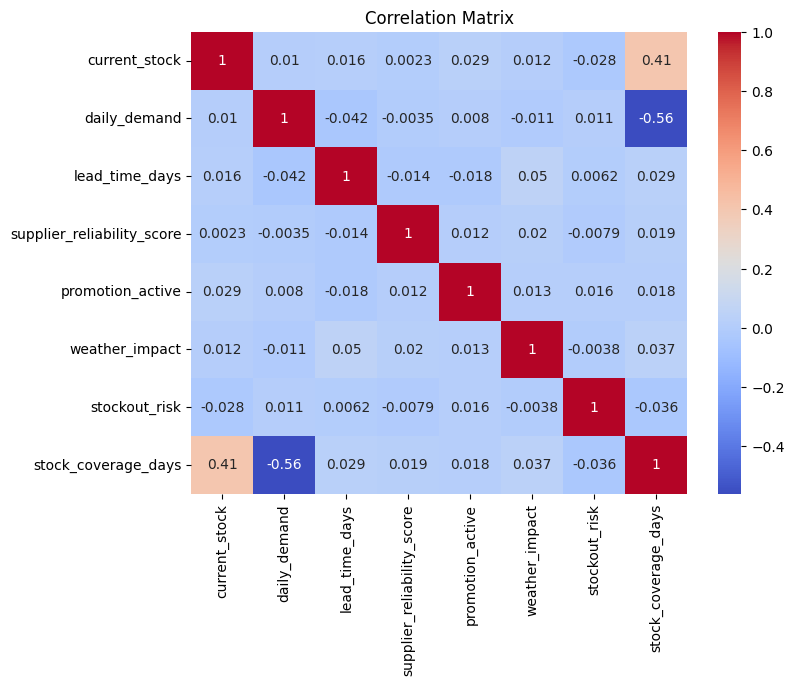

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

corr_matrix = df_clean.select_dtypes(include=['number']).corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

stockout_risk is has high positive correlation with daily demand and promotion_active. Also has little positive correlation with lead_time_days.

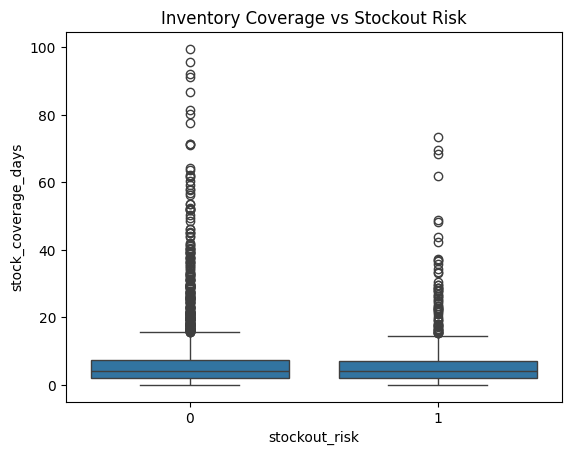

In [28]:
sns.boxplot(x="stockout_risk", y="stock_coverage_days", data=df_clean)

plt.title("Inventory Coverage vs Stockout Risk")

plt.show()

Products with lower inventory coverage days show significantly higher stockout risk.

Text(0, 0.5, 'Average Daily Demand')

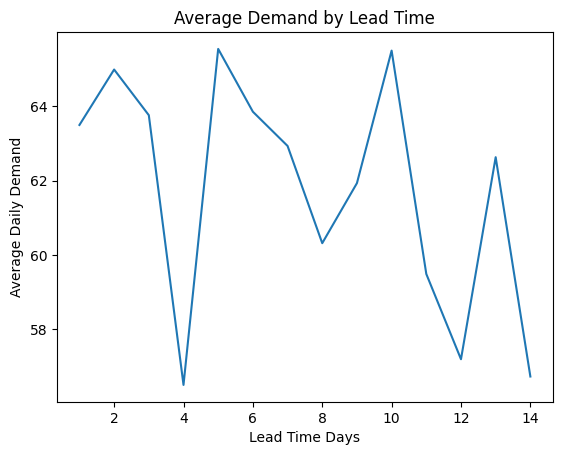

In [29]:
df_clean.groupby("lead_time_days")["daily_demand"].mean().plot()

plt.title("Average Demand by Lead Time")
plt.xlabel("Lead Time Days")
plt.ylabel("Average Daily Demand")


Demand does not strongly depend on supplier lead time.

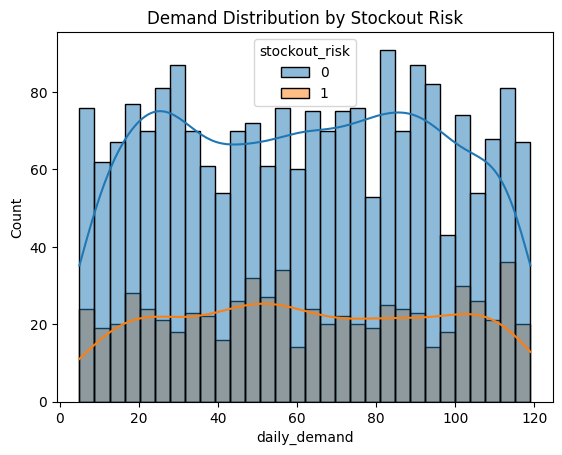

In [30]:
sns.histplot(
    data=df_clean,
    x="daily_demand",
    hue="stockout_risk",
    bins=30,
    kde=True
)

plt.title("Demand Distribution by Stockout Risk")
plt.show()

The demand distribution for stockout and non-stockout cases shows significant overlap, indicating that demand alone does not fully explain stockout events. Stockouts are more likely influenced by the interaction of demand, inventory levels, and supplier lead times.

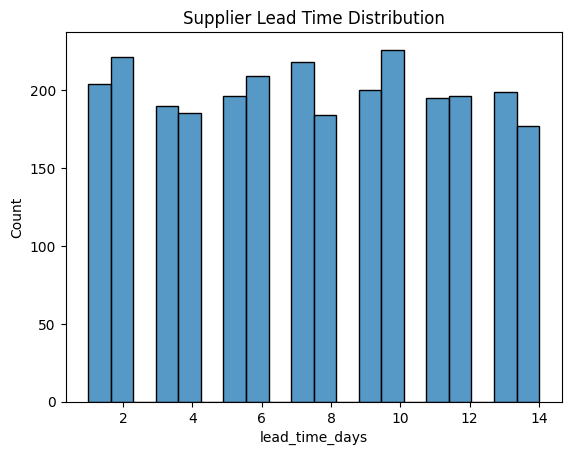

In [31]:
sns.histplot(df_clean["lead_time_days"], bins=20)

plt.title("Supplier Lead Time Distribution")

plt.show()

Supplier lead times vary across products, creating supply chain uncertainty that may increase stockout risk.

<Axes: xlabel='stockout_risk', ylabel='current_stock'>

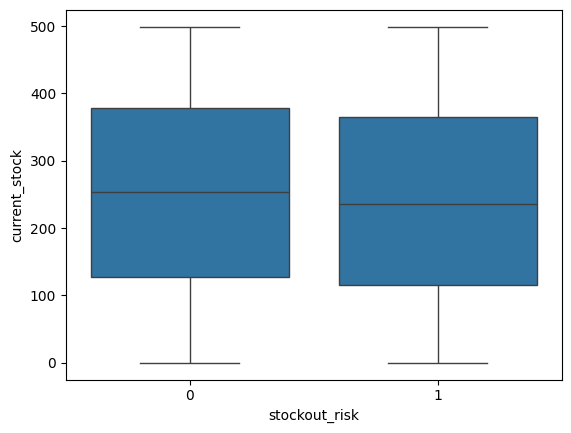

In [32]:
sns.boxplot(x="stockout_risk", y="current_stock", data=df_clean)

Above graph somewhat confirms that stockout has some dependence on current stock.

In [33]:
df_clean.groupby("store_id")["stockout_risk"].sum().sort_values(ascending=False).head(10)

,stockout_risk
store_id,
S2,46
S1,44
S9,43
S8,40
S3,38
S14,38
S13,37
S18,37
S19,36


Above are the stores with most stock out risks.

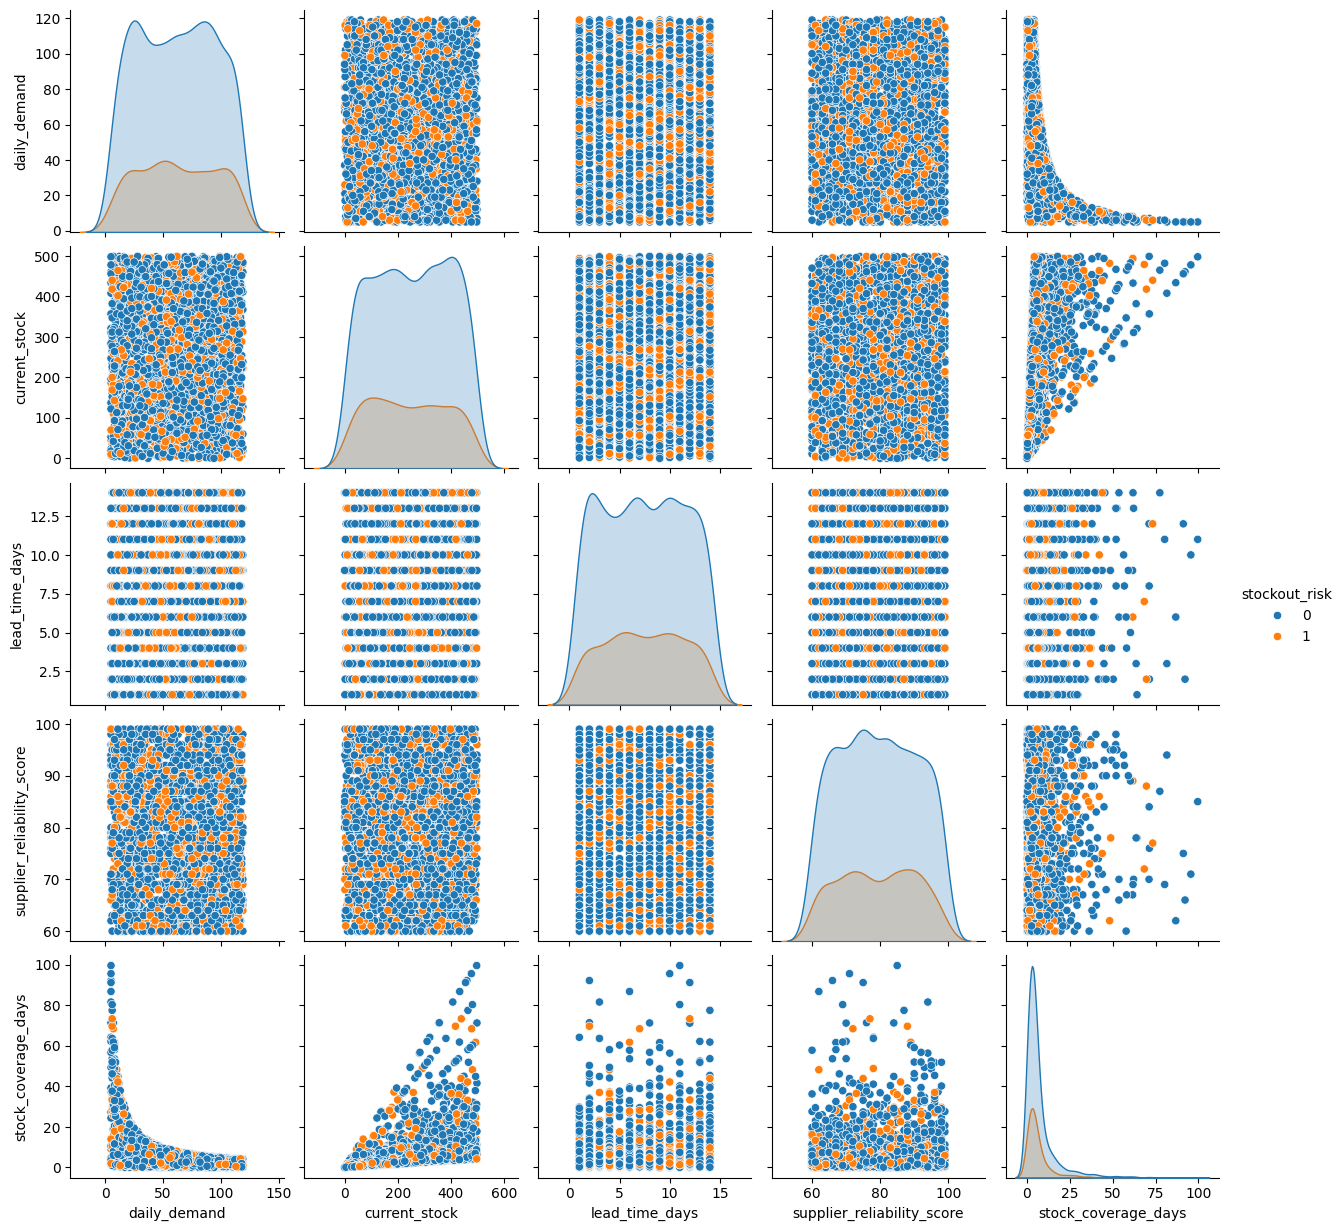

In [34]:
sns.pairplot(df_clean[[
    "daily_demand",
    "current_stock",
    "lead_time_days",
    "supplier_reliability_score",
    "stock_coverage_days",
    "stockout_risk"
]], hue="stockout_risk")

Demand alone does not completely explain stockouts.
Demand alone does not completely explain stockouts.
higher stock → higher coverage
higher demand → lower coverage
Lead time alone is not a strong predictor of stockouts.
Supplier reliability does not appear to strongly explain stockout risk in isolation.
**Low inventory coverage combined with high demand increases stockout risk.

Key Insights from Pairplot Analysis

1. Daily demand varies widely across products but does not independently explain stockout events.
2. Stock coverage days show a strong relationship with stockout risk, with lower coverage associated with higher stockout occurrences.
3. Lead time and supplier reliability show weaker individual relationships with stockout risk.
4. Inventory coverage, which combines demand and stock levels, appears to be the most important operational metric affecting stockouts.

#Day5


In [42]:
X = df_clean.drop(["stockout_risk","product_id","store_id","date"], axis=1)
y = df_clean["stockout_risk"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [46]:
y_pred = log_model.predict(X_test)

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      1.00      0.87       428
           1       0.00      0.00      0.00       132

    accuracy                           0.76       560
   macro avg       0.38      0.50      0.43       560
weighted avg       0.58      0.76      0.66       560



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The model predicted zero samples for class 1, hence imbalanced model.

In [56]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.44      0.55       428
           1       0.22      0.50      0.30       132

    accuracy                           0.46       560
   macro avg       0.48      0.47      0.43       560
weighted avg       0.62      0.46      0.49       560



After applying class balancing, the model began detecting stockout events, achieving a recall of 50% for the stockout class. While overall accuracy decreased, the model became more useful for operational decision-making by identifying potential stockout risks.

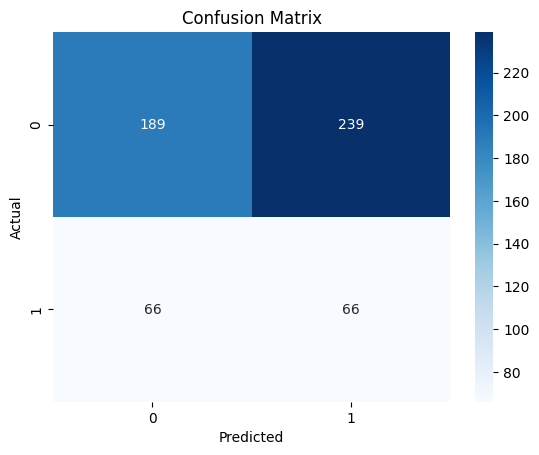

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.77      0.98      0.86       428
           1       0.36      0.04      0.07       132

    accuracy                           0.76       560
   macro avg       0.56      0.51      0.46       560
weighted avg       0.67      0.76      0.67       560



Logistic Regression detects stockouts.
Random Forest misses most stockouts.

Detecting stockouts is more important.

The Random Forest model achieved higher overall accuracy (75%) but failed to detect most stockout events, with a recall of only 4%. In contrast, the balanced Logistic Regression model achieved lower accuracy but significantly better stockout detection, making it more suitable for identifying potential inventory risks.

In [60]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

importance

,Feature,Coefficient
4,promotion_active,0.082876
5,weather_impact,0.029575
2,lead_time_days,0.006559
0,current_stock,0.000067
3,supplier_reliability_score,-0.000415
1,daily_demand,-0.002036
6,stock_coverage_days,-0.013762


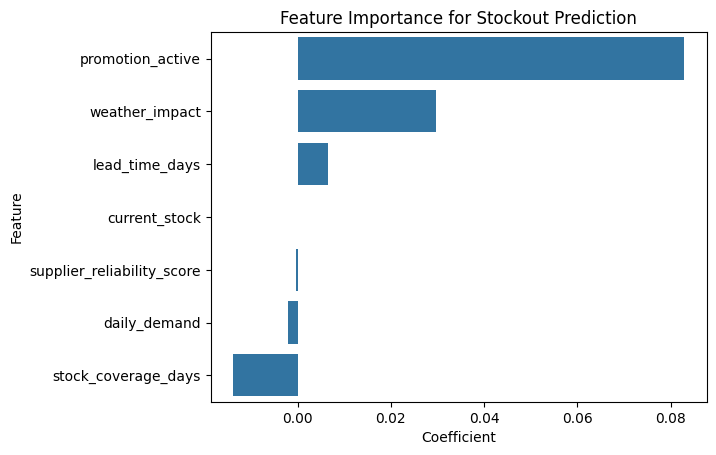

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Coefficient", y="Feature", data=importance)

plt.title("Feature Importance for Stockout Prediction")

plt.show()

Key Drivers of Stockout Risk:

Promotional campaigns significantly increase stockout probability due to sudden demand spikes.

Weather conditions influence demand patterns and contribute to inventory shortages.

Longer supplier lead times increase the likelihood of stockouts by delaying replenishment.

Higher inventory coverage significantly reduces stockout risk, making it a critical metric for inventory planning.